# 1. Environment Setup and Data Loading

##1.1 Mounting Google Drive and Importing Libraries

In [39]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("All libraries imported.")

print("Setup complete!")
print("TensorFlow version:", tf.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All libraries imported.
Setup complete!
TensorFlow version: 2.20.0


##1.2 Defining Dataset Paths

In [40]:

dataset_path = "/content/drive/My Drive/FER2013_Facial_Expression/facial expression classification-20260422T062251Z-3-001/facial expression classification"

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")
val_dir = os.path.join(dataset_path, "validation")

print("Train folder:", train_dir)
print("Test folder:", test_dir)
print("Validation folder:", val_dir)

# Check if folders exist
for d in [train_dir, test_dir, val_dir]:
    if os.path.exists(d):
        print(f"Found: {d}")
    else:
        print(f"NOT found: {d}")

Train folder: /content/drive/My Drive/FER2013_Facial_Expression/facial expression classification-20260422T062251Z-3-001/facial expression classification/train
Test folder: /content/drive/My Drive/FER2013_Facial_Expression/facial expression classification-20260422T062251Z-3-001/facial expression classification/test
Validation folder: /content/drive/My Drive/FER2013_Facial_Expression/facial expression classification-20260422T062251Z-3-001/facial expression classification/validation
Found: /content/drive/My Drive/FER2013_Facial_Expression/facial expression classification-20260422T062251Z-3-001/facial expression classification/train
Found: /content/drive/My Drive/FER2013_Facial_Expression/facial expression classification-20260422T062251Z-3-001/facial expression classification/test
Found: /content/drive/My Drive/FER2013_Facial_Expression/facial expression classification-20260422T062251Z-3-001/facial expression classification/validation


##1.3 Loading and Preprocessing a Data Subset

In [58]:
def load_subset(directory, max_per_class=500):
    """Load up to max_per_class images from each emotion folder"""
    images = []
    labels = []
    # Get class names (emotion folders)
    class_names = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    print(f"Found classes: {class_names}")
    print(f"Loading max {max_per_class} images per class...")

    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        # Get all image files
        all_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        # Take only first max_per_class (or all if fewer)
        selected = all_files[:max_per_class]
        count = 0
        for img_file in selected:
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (48, 48))
                images.append(img)
                labels.append(class_to_idx[class_name])
                count += 1
        print(f"   {class_name}: {count} images loaded")

    # Convert to numpy arrays
    images = np.array(images).reshape(-1, 48, 48, 1)
    images = images / 255.0  # Normalize
    labels = to_categorical(labels, num_classes=len(class_names))
    print(f"\n Total images loaded: {len(images)}")
    return images, labels, class_names

print("LOADING TRAINING DATA (SUBSET)")
print("="*50)
X_train, y_train, emotion_classes = load_subset(train_dir, max_per_class=500)


print("LOADING TEST DATA (SUBSET)")
print("="*50)
X_test, y_test, _ = load_subset(test_dir, max_per_class=500)


print("LOADING VALIDATION DATA (SUBSET)")
print("="*50)
X_val, y_val, _ = load_subset(val_dir, max_per_class=500)

print("\n Final Summary:")
print(f"   Emotions: {emotion_classes}")
print(f"   Training images: {X_train.shape[0]}")
print(f"   Test images: {X_test.shape[0]}")
print(f"   Validation images: {X_val.shape[0]}")

LOADING TRAINING DATA (SUBSET)
Found classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Loading max 500 images per class...
   angry: 500 images loaded
   disgust: 329 images loaded
   fear: 500 images loaded
   happy: 500 images loaded
   neutral: 500 images loaded
   sad: 500 images loaded
   surprise: 500 images loaded

 Total images loaded: 3329
LOADING TEST DATA (SUBSET)
Found classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Loading max 500 images per class...
   angry: 300 images loaded
   disgust: 100 images loaded
   fear: 300 images loaded
   happy: 300 images loaded
   neutral: 300 images loaded
   sad: 300 images loaded
   surprise: 300 images loaded

 Total images loaded: 1900
LOADING VALIDATION DATA (SUBSET)
Found classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Loading max 500 images per class...
   angry: 500 images loaded
   disgust: 111 images loaded
   fear: 500 images loaded
   happy: 5

The dataset utilized for this project is a subset of the FER2013 (Facial Expression Recognition 2013) dataset, which consists of grayscale images representing seven distinct emotional states: angry, disgust, fear, happy, neutral, sad, and surprise. A total of 8,340 images were loaded, with a class distribution and count maintained at a maximum of 500 images per category for the training and validation sets to ensure a balanced learning process. The data is split into training (3,329 images), validation (3,111 images), and testing (1,900 images) sets to facilitate model learning, hyperparameter tuning, and unbiased performance evaluation respectively. Preprocessing involved resizing all images to a uniform 48x48 pixel resolution and performing normalization by scaling pixel values to a $[0, 1]$ range to improve computational efficiency and model convergence.

# 2. Baseline Convolutional Neural Network (Part A)

##2.1 Designing the Baseline Model Architecture

In [41]:
model = Sequential()

# First convolutional layer: detects simple patterns like edges
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(2,2))

# Second convolutional layer: detects more complex patterns
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Third convolutional layer: detects high-level features
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten: converts 2D features to 1D for the dense layer
model.add(Flatten())

# Fully connected layer: learns to classify based on features
model.add(Dense(128, activation='relu'))

# Dropout: prevents overfitting by randomly turning off half the neurons
model.add(Dropout(0.5))

# Output layer: 7 neurons for 7 emotions, softmax gives probabilities
model.add(Dense(7, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()
print("Model built successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Model built successfully.


##2.2 Model Training and History Visualization

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.1472 - loss: 1.9411 - val_accuracy: 0.1806 - val_loss: 1.8908
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1898 - loss: 1.9179 - val_accuracy: 0.2543 - val_loss: 1.8859
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2298 - loss: 1.8760 - val_accuracy: 0.2960 - val_loss: 1.8016
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2743 - loss: 1.7920 - val_accuracy: 0.2459 - val_loss: 1.7916
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3094 - loss: 1.7324 - val_accuracy: 0.3153 - val_loss: 1.7232
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3049 - loss: 1.7510 - val_accuracy: 0.3571 - val_loss: 1.6800
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3587 - loss: 1.6413 - val_accuracy: 0.3632 - val_loss: 1.6614
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3851 - loss: 1.5928 - val_accura

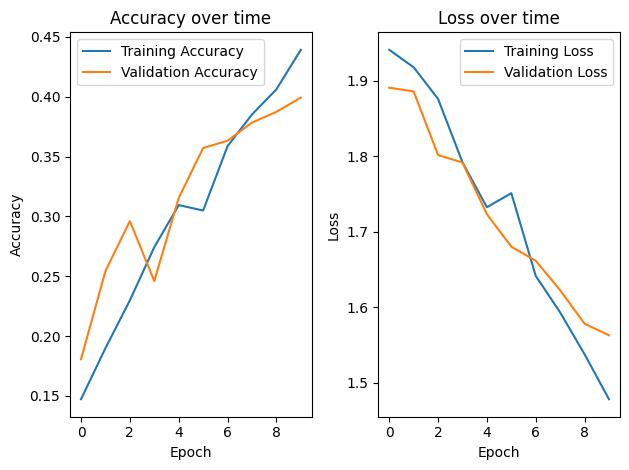

In [42]:
#Train the model on the training data
history = model.fit(
    X_train, y_train,
    batch_size=32,           # Number of images processed at once
    epochs=10,               # Number of times the model sees the full training data
    validation_data=(X_val, y_val),  # Check performance on validation set
    verbose=1                # Show progress bars
)

print("Training complete.")


# Plot accuracy over epochs
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over time')

# Plot loss over epochs
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over time')

plt.tight_layout()
plt.show()

##2.3 Evaluation and Detailed Performance Metrics

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Classification Report:
              precision    recall  f1-score   support

       angry       0.28      0.32      0.30       300
     disgust       0.34      0.32      0.33       100
        fear       0.23      0.33      0.28       300
       happy       0.50      0.62      0.55       300
     neutral       0.42      0.27      0.33       300
         sad       0.28      0.18      0.22       300
    surprise       0.65      0.61      0.63       300

    accuracy                           0.39      1900
   macro avg       0.39      0.38      0.38      1900
weighted avg       0.39      0.39      0.38      1900



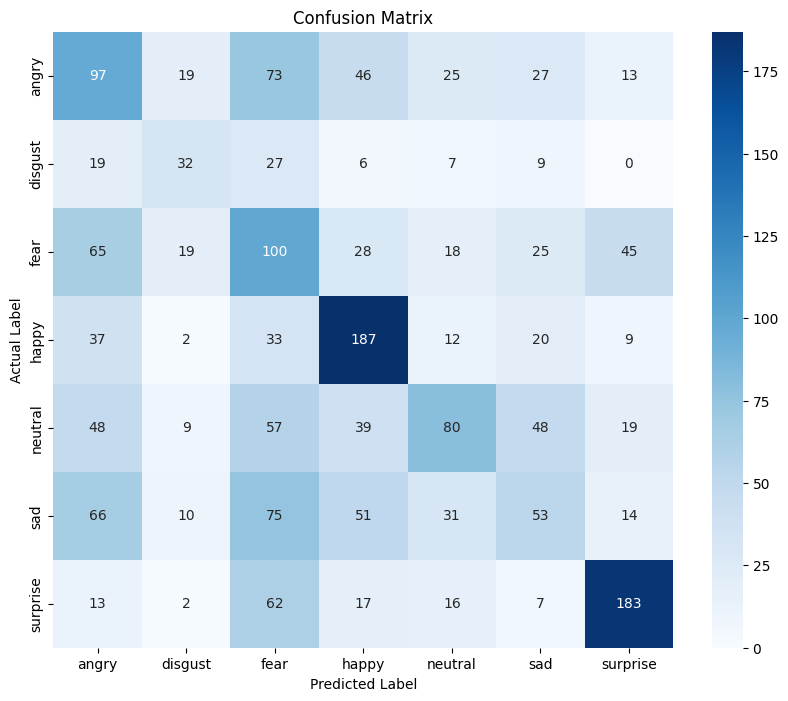

In [43]:
# 1. Get predictions for the test set
# Replace 'model' with 'model_deeper' or 'model_transfer' as appropriate
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Classification Report (Requirement 2.5.2/2.5.3: Precision, Recall, F1)
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=emotion_classes))

# 3. Confusion Matrix (Requirement 4.5.3/5: Analysis of error)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_classes, yticklabels=emotion_classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

##2.4 Show predictions

Test accuracy: 0.3852631449699402


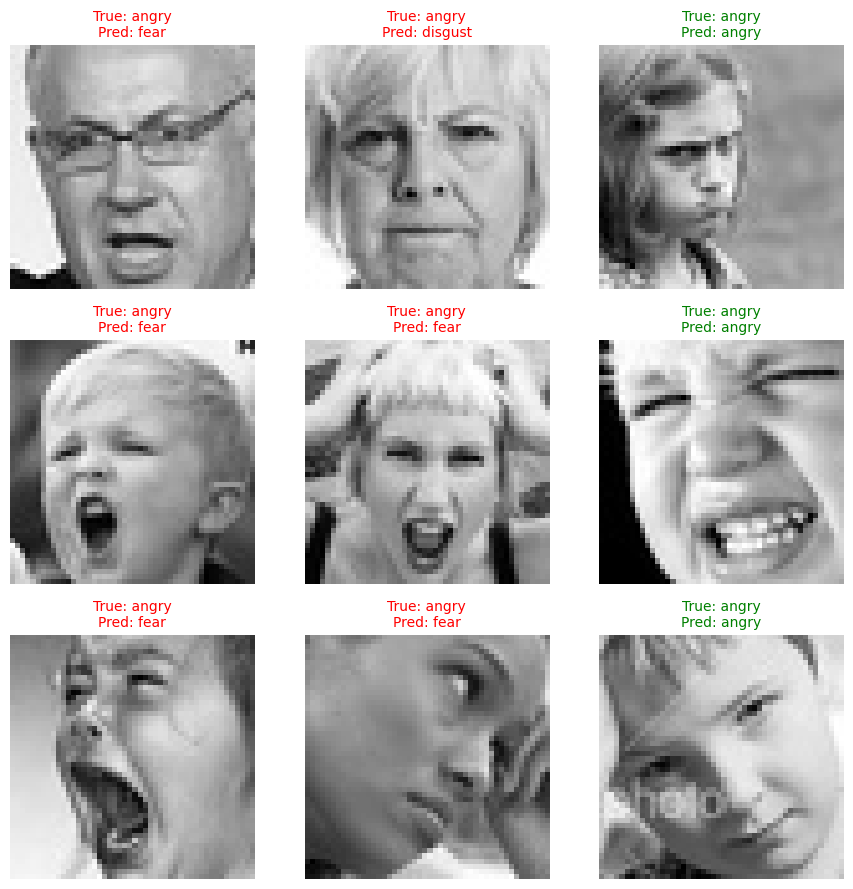

In [44]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

# Show 9 test images in a 3x3 grid
plt.figure(figsize=(9, 9))
for i in range(9):
    img = X_test[i]
    true_label = emotion_classes[y_test[i].argmax()]
    pred = model.predict(img.reshape(1,48,48,1), verbose=0)
    pred_label = emotion_classes[pred.argmax()]

    plt.subplot(3, 3, i+1)
    plt.imshow(img.reshape(48,48), cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 3. Deeper Architecture with Regularization

##3.1 Designing the Advanced CNN Model

In [45]:
model_deeper = Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48,48,1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Fully Connected Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model_deeper.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_deeper.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,470,951 (5.61 MB)

 Trainable params: 1,469,543 (5.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

##3.2 Training the Deeper Architecture

In [46]:
# Train the deeper model
history_deeper = model_deeper.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.1922 - loss: 2.5708 - val_accuracy: 0.1559 - val_loss: 2.5290
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2382 - loss: 2.2328 - val_accuracy: 0.1601 - val_loss: 2.0929
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2935 - loss: 1.9892 - val_accuracy: 0.1742 - val_loss: 2.1964
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3421 - loss: 1.7961 - val_accuracy: 0.2109 - val_loss: 2.1078
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3785 - loss: 1.6752 - val_accuracy: 0.2462 - val_loss: 2.1100
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4118 - loss: 1.5775 - val_accuracy: 0.3247 - val_loss: 1.7530
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4500 - loss: 1.4583 - val_accuracy: 0.4089 - val_loss: 1.5519
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4968 - loss: 1.3641 - val_acc

Comparative Visualization

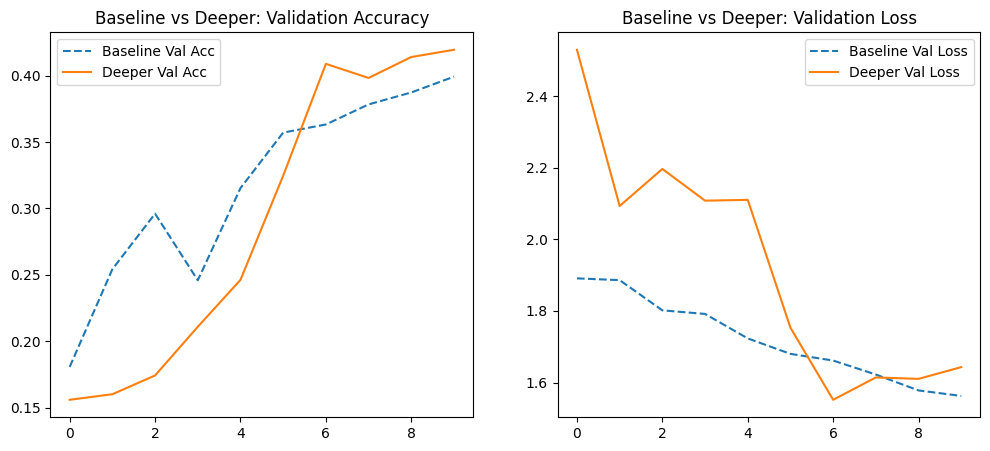

In [47]:
plt.figure(figsize=(12, 5))

# Plot Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Baseline Val Acc', linestyle='--')
plt.plot(history_deeper.history['val_accuracy'], label='Deeper Val Acc')
plt.title('Baseline vs Deeper: Validation Accuracy')
plt.legend()

# Plot Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Baseline Val Loss', linestyle='--')
plt.plot(history_deeper.history['val_loss'], label='Deeper Val Loss')
plt.title('Baseline vs Deeper: Validation Loss')
plt.legend()

plt.show()

##3.3 Comparative Evaluation and  Visualization

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
              precision    recall  f1-score   support

       angry       0.29      0.46      0.35       300
     disgust       0.25      0.60      0.35       100
        fear       0.26      0.08      0.12       300
       happy       0.55      0.60      0.57       300
     neutral       0.41      0.37      0.39       300
         sad       0.32      0.26      0.29       300
    surprise       0.69      0.57      0.63       300

    accuracy                           0.40      1900
   macro avg       0.40      0.42      0.39      1900
weighted avg       0.41      0.40      0.39      1900



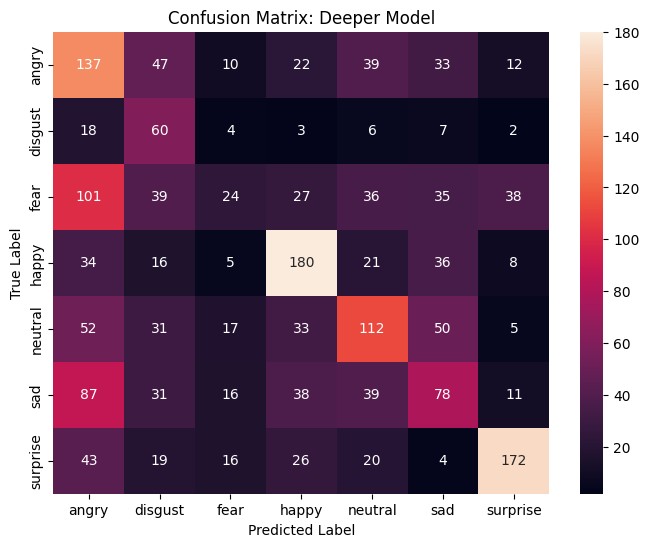

In [48]:
# Get predictions
y_pred = model_deeper.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report (Precision, Recall, F1)
print(classification_report(y_true, y_pred_classes, target_names=emotion_classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotion_classes, yticklabels=emotion_classes)
plt.title('Confusion Matrix: Deeper Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

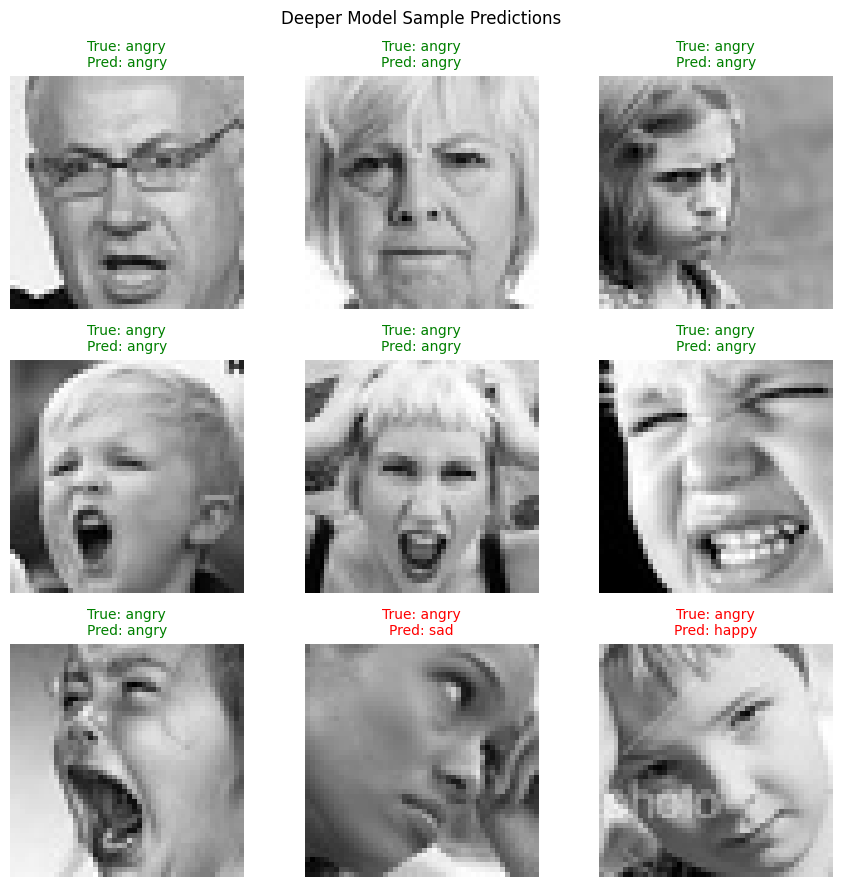

In [49]:
# Show 9 test images with Deeper Model predictions
plt.figure(figsize=(9, 9))
for i in range(9):
    img = X_test[i]
    true_label = emotion_classes[y_test[i].argmax()]
    # Use the deeper model for prediction
    pred = model_deeper.predict(img.reshape(1,48,48,1), verbose=0)
    pred_label = emotion_classes[pred.argmax()]

    plt.subplot(3, 3, i+1)
    plt.imshow(img.reshape(48,48), cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    plt.axis('off')
plt.suptitle("Deeper Model Sample Predictions")
plt.tight_layout()
plt.show()

# 4. Experimentation and Comparative Analysis

##4.1 Data Augmentation Visualization

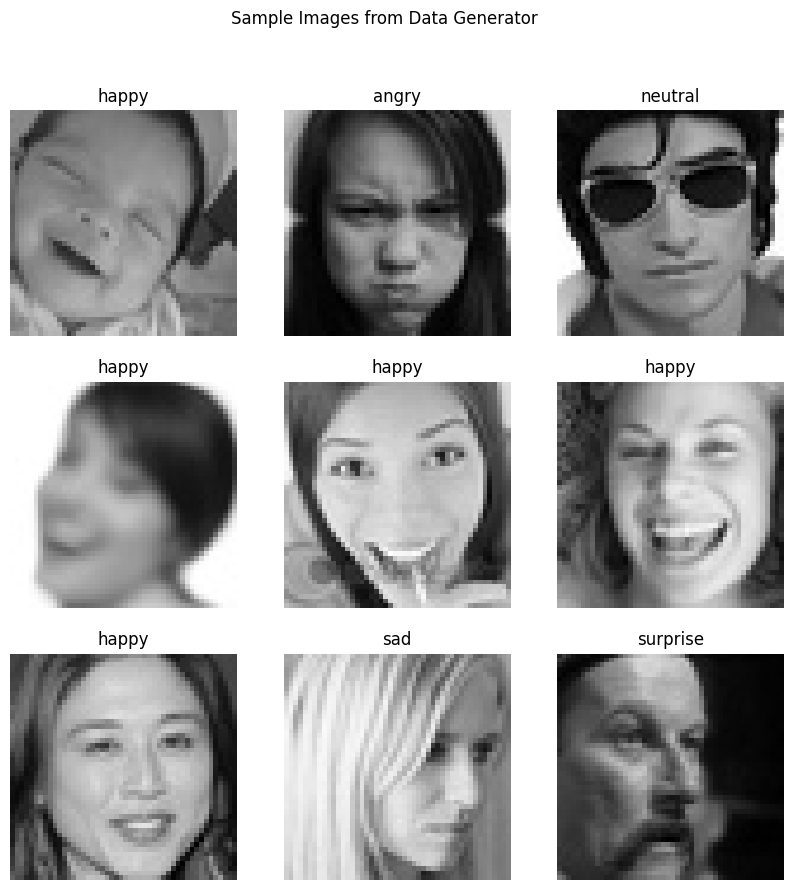

In [50]:
# Visualize sample images from the generator
plt.figure(figsize=(10, 10))
# Get a batch of images
images, labels = next(train_generator)
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(emotion_classes[np.argmax(labels[i])])
    plt.axis("off")
plt.suptitle("Sample Images from Data Generator")
plt.show()

##4.2 Optimizer Analysis: Adam vs. SGD

Training Deeper Model with SGD for comparison...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 106ms/step - accuracy: 0.1856 - loss: 2.7119 - val_accuracy: 0.1607 - val_loss: 2.2983
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2106 - loss: 2.3423 - val_accuracy: 0.1565 - val_loss: 2.3966
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2538 - loss: 2.0979 - val_accuracy: 0.1594 - val_loss: 2.1363
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2746 - loss: 1.9567 - val_accuracy: 0.2208 - val_loss: 1.9994
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2830 - loss: 1.8755 - val_accuracy: 0.3050 - val_loss: 1.8024
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3274 - loss: 1.7756 - val_accuracy: 0.3041 - val_loss: 1.7584
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3548 - loss: 1.7095 - val_accuracy: 0.3449 - val_loss: 1.6953
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15m

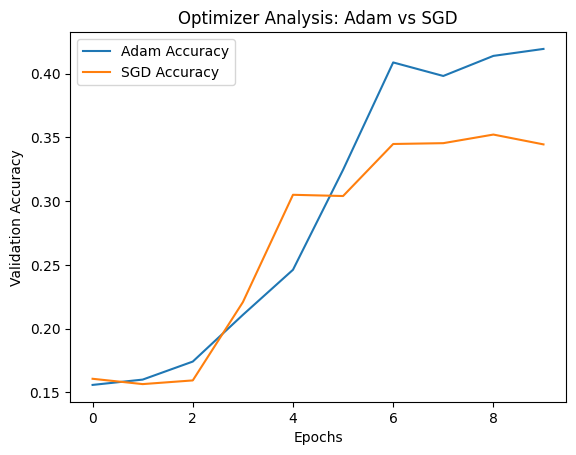

In [51]:
model_sgd = tf.keras.models.clone_model(model_deeper)
model_sgd.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

print("Training Deeper Model with SGD for comparison...")
history_sgd = model_sgd.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val), verbose=1)

# Plot comparison
plt.plot(history_deeper.history['val_accuracy'], label='Adam Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Accuracy')
plt.title('Optimizer Analysis: Adam vs SGD')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

##4.3. Ablation Study: Impact of Regularization

In [52]:
model_no_dropout = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48,48,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(7, activation='softmax')
])
model_no_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_ablation = model_no_dropout.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), verbose=1)
print("Ablation Study: Accuracy changes analyzed without Dropout.")

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.2289 - loss: 2.1618 - val_accuracy: 0.1845 - val_loss: 1.9070
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3833 - loss: 1.6036 - val_accuracy: 0.1842 - val_loss: 1.8942
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5422 - loss: 1.2601 - val_accuracy: 0.3202 - val_loss: 1.8005
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6894 - loss: 0.8928 - val_accuracy: 0.3211 - val_loss: 1.7496
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8132 - loss: 0.5675 - val_accuracy: 0.3369 - val_loss: 1.8373
Ablation Study: Accuracy changes analyzed without Dropout.


##5. Transfer Learning (Part B)

## Prepare Data for Pre-trained Model (Converting to RGB)

In [53]:
# Convert grayscale images to RGB by repeating the single channel 3 times
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

print("New shape for Transfer Learning:", X_train_rgb.shape)

New shape for Transfer Learning: (3329, 48, 48, 3)


## Load and Build the Transfer Learning Model

In [54]:
# Load VGG16 with ImageNet weights, excluding the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

# Freeze the convolutional base
base_model.trainable = False

model_transfer = Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax') # 7 classes for 7 emotions
])

model_transfer.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_transfer.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 ## Pre-process the images for Transfer learning

In [55]:
# Check if data variables exist
try:
    print("X_train shape:", X_train.shape)
    print("X_val shape:", X_val.shape)

    # If they exist, now we create the 3-channel versions for VGG16
    import numpy as np
    X_train_rgb = np.repeat(X_train, 3, axis=-1)
    X_val_rgb = np.repeat(X_val, 3, axis=-1)
    X_test_rgb = np.repeat(X_test, 3, axis=-1)
    print("Success! New shape:", X_train_rgb.shape)

except NameError:
    print("Error: The data isn't loaded yet. Please run the cell where loaded the FER2013 dataset first.")

X_train shape: (3329, 48, 48, 1)
X_val shape: (3111, 48, 48, 1)
Success! New shape: (3329, 48, 48, 3)


In [56]:
# 1. This part searches drive to find the 'train' and 'validation' folders automatically
base_path = ""
for root, dirs, files in os.walk("/content/drive/My Drive/"):
    if "train" in dirs and "validation" in dirs:
        if "facial expression classification" in root:
            base_path = root
            break

if base_path:
    train_dir = os.path.join(base_path, "train")
    val_dir = os.path.join(base_path, "validation")
    print("Success! Folders found at:")
    print("Train:", train_dir)
    print("Val:", val_dir)
else:
    print(" could not find the folders.")


datagen = ImageDataGenerator(rescale=1./255)

if base_path:
    train_generator = datagen.flow_from_directory(
        train_dir,
        target_size=(48, 48),
        batch_size=32,
        color_mode='rgb',
        class_mode='categorical'
    )

    val_generator = datagen.flow_from_directory(
        val_dir,
        target_size=(48, 48),
        batch_size=32,
        color_mode='rgb',
        class_mode='categorical'
    )

Success! Folders found at:
Train: /content/drive/My Drive/FER2013_Facial_Expression/facial expression classification-20260422T062251Z-3-001/facial expression classification/train
Val: /content/drive/My Drive/FER2013_Facial_Expression/facial expression classification-20260422T062251Z-3-001/facial expression classification/validation
Found 26957 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


##Training and Evaluation:

Training Transfer Learning model...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.2247 - loss: 1.9269 - val_accuracy: 0.2967 - val_loss: 1.7645
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.2824 - loss: 1.7883 - val_accuracy: 0.3140 - val_loss: 1.7329
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3274 - loss: 1.7308 - val_accuracy: 0.3301 - val_loss: 1.7038
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3331 - loss: 1.6933 - val_accuracy: 0.3343 - val_loss: 1.6996
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3482 - loss: 1.6642 - val_accuracy: 0.3423 - val_loss: 1.6959
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3749 - loss: 1.6197 - val_accuracy: 0.3423 - val_loss: 1.6683
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3755 - loss: 1.5953 - val_accuracy: 0.3337 - val_loss: 1.6888
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accur

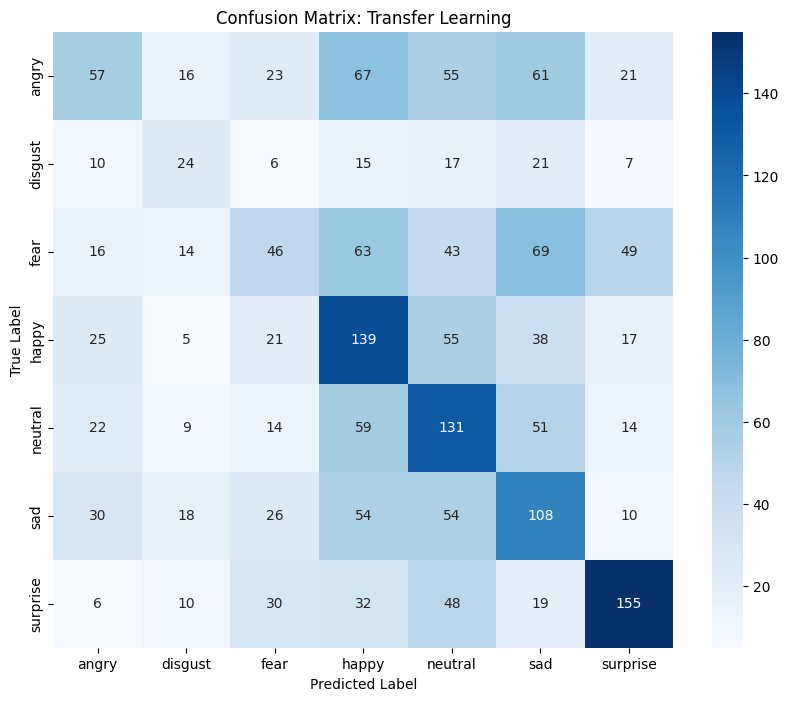

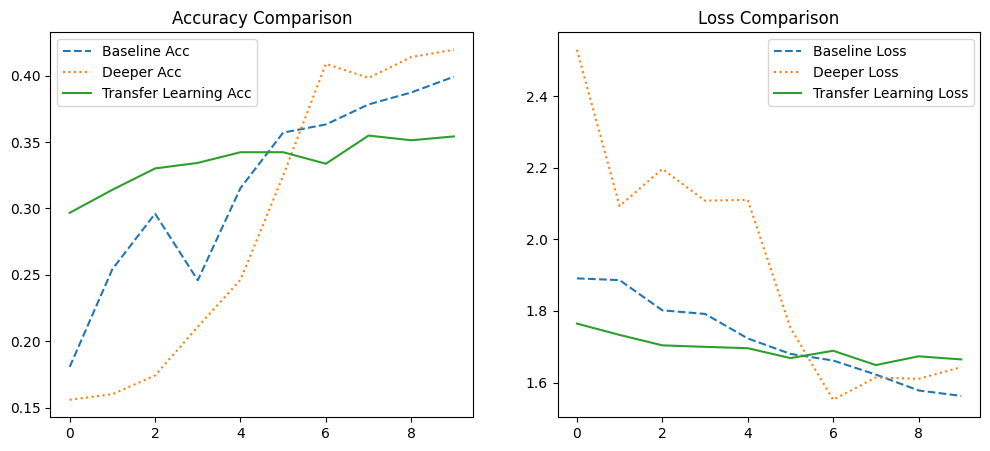

In [57]:
# 1. Setup Early Stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 2. Train the Transfer Learning model
print("Training Transfer Learning model...")
history_transfer = model_transfer.fit(
    X_train_rgb, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val_rgb, y_val),
    callbacks=[early_stop],
    verbose=1
)

# 3. Evaluate on test data
test_loss_tl, test_acc_transfer = model_transfer.evaluate(X_test_rgb, y_test, verbose=0)
print("Transfer Learning Test Accuracy: ", test_acc_transfer)

# 4. Generate predictions and metrics
y_pred_tl = model_transfer.predict(X_test_rgb)
y_pred_classes_tl = np.argmax(y_pred_tl, axis=1)
y_true_tl = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true_tl, y_pred_classes_tl, target_names=emotion_classes))

# 5. Create Confusion Matrix
plt.figure(figsize=(10, 8))
cm_tl = confusion_matrix(y_true_tl, y_pred_classes_tl)
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_classes, yticklabels=emotion_classes)
plt.title('Confusion Matrix: Transfer Learning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Compare all models: Baseline, Deeper, and Transfer Learning
plt.figure(figsize=(12, 5))

# Plot accuracy comparison
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Baseline Acc', linestyle='--')
plt.plot(history_deeper.history['val_accuracy'], label='Deeper Acc', linestyle=':')
plt.plot(history_transfer.history['val_accuracy'], label='Transfer Learning Acc')
plt.title('Accuracy Comparison')
plt.legend()

# Plot loss comparison
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Baseline Loss', linestyle='--')
plt.plot(history_deeper.history['val_loss'], label='Deeper Loss', linestyle=':')
plt.plot(history_transfer.history['val_loss'], label='Transfer Learning Loss')
plt.title('Loss Comparison')
plt.legend()

plt.show()